In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
# one-time per session (fast reuse during the session)
!rsync -ah --info=progress2 "/content/drive/MyDrive/luna16/" "/content/luna16_local/"

import os, pathlib as pl
os.environ['LUNA16_ROOT'] = "/content/luna16_local"
assert pl.Path(os.environ['LUNA16_ROOT']).joinpath("annotations.csv").exists()
print("[colab] Using local LUNA16 at", os.environ['LUNA16_ROOT'])


Mounted at /content/drive
        128.91M   0%   13.28MB/s    0:00:09 (xfr#9, ir-chk=2845/2868)rsync error: received SIGINT, SIGTERM, or SIGHUP (code 20) at io.c(519) [generator=3.2.7]

rsync error: received SIGINT, SIGTERM, or SIGHUP (code 20) at rsync.c(716) [sender=3.2.7]
rsync: [generator] write error: Broken pipe (32)
[colab] Using local LUNA16 at /content/luna16_local


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%pip -q install monai itk SimpleITK nibabel pydicom
import os
os.environ["ARCH3D"] = "densenet121"  # or "unetenc"

# === Imports & config ===
import os, re, glob, json, math, random, shutil, pathlib as pl
from contextlib import nullcontext

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

# Keep things stable & light
os.environ.setdefault("ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

RNG_SEED = 42
random.seed(RNG_SEED); np.random.seed(RNG_SEED); torch.manual_seed(RNG_SEED)

# Enable fast paths
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True  # fixed-size 3D patches -> autotune fast convs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (DEVICE.type == "cuda")

# Modern AMP API (fixes deprecation)
amp_ctx = (lambda: torch.autocast(device_type="cuda", dtype=torch.float16)) if use_amp else (lambda: nullcontext())
scaler  = torch.amp.GradScaler(enabled=use_amp, device="cuda")

print(f"[setup] Device: {DEVICE}  | torch {torch.__version__} | cuda: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 

In [ ]:
# === Helpers ===
import re, glob, pathlib as pl
import pandas as pd
import os

def _exists(p):
    try: return pl.Path(p).exists()
    except: return False

def subset_dirs_under(root: pl.Path):
    return [p for p in root.glob("subset*") if p.is_dir()]

def seriesuid_from_path(p: str) -> str:
    return pl.Path(p).stem

def subset_name_from_path(p: str) -> str:
    parts = pl.Path(p).parts
    for comp in reversed(parts):
        if re.match(r"^subset\d+$", comp):
            return comp
    return "subset?"

# === Locate MAIN LUNA (Colab: single Drive folder) ===
MAIN_ROOT = pl.Path(os.environ.get("LUNA16_ROOT", "/content/drive/MyDrive/luna16")).resolve()
assert (MAIN_ROOT / "annotations.csv").exists(), f"Missing annotations.csv under {MAIN_ROOT}"
print("[data] MAIN LUNA16 ROOT =", MAIN_ROOT)

# === Gather all subset* dirs (only under MAIN_ROOT) ===
all_subset_dirs = subset_dirs_under(MAIN_ROOT)
assert all_subset_dirs, "No subset* dirs found under MAIN_ROOT."
print("[data] Found subset roots:")
for sd in sorted(all_subset_dirs, key=lambda p: p.name):
    print(" -", sd)

# === Discover all .mhd paths ===
def find_mhds(subset_dir: pl.Path):
    return sorted(set(
        glob.glob(str(subset_dir / "*.mhd")) +
        glob.glob(str(subset_dir / "*/*.mhd")) +
        glob.glob(str(subset_dir / "*/*/*.mhd"))
    ))

mhd_paths = []
for sdir in all_subset_dirs:
    mhd_paths += find_mhds(sdir)
mhd_paths = sorted(set(mhd_paths))
print(f"[data] Found {len(mhd_paths)} .mhd files across {len(all_subset_dirs)} subset roots.")

# Table of scans
scans_df = pd.DataFrame({
    "seriesuid": [seriesuid_from_path(p) for p in mhd_paths],
    "mhd_path": mhd_paths,
    "subset":   [subset_name_from_path(p) for p in mhd_paths],
}).drop_duplicates("seriesuid").reset_index(drop=True)

# === Labels from annotations.csv (≥1 nodule => positive) ===
ann = pd.read_csv(MAIN_ROOT / "annotations.csv")
pos_set = set(ann["seriesuid"].unique())
scans_df["label"] = scans_df["seriesuid"].isin(pos_set).astype(int)
print("[data] Class balance (0=neg,1=pos):")
print(scans_df["label"].value_counts())

# === Find lung masks (optional; for cropping/znorm) ===
lung_roots = []
def collect_lung_roots(base: pl.Path):
    for cand in [base / "seg-lungs-LUNA16", base / "seg-lungs-LUNA16" / "seg-lungs-LUNA16"]:
        if cand.exists(): lung_roots.append(cand.resolve())

# search in MAIN root and in parents of discovered subset dirs
for root in {MAIN_ROOT, *{sd.parent for sd in all_subset_dirs}}:
    collect_lung_roots(root)
lung_roots = list(dict.fromkeys(lung_roots))  # unique-preserving

def find_lung_mask_path(uid: str):
    for root in lung_roots:
        for ext in (".nii.gz", ".nii", ".mhd"):
            hits = glob.glob(str(root / f"**/{uid}{ext}"), recursive=True)
            if hits: return hits[0]
    return None

scans_df["lung"] = scans_df["seriesuid"].map(find_lung_mask_path)
print("[data] Lung masks found for", scans_df["lung"].notna().sum(), "of", len(scans_df), "scans.")

# === Optional: locate candidate CSVs (inside MAIN_ROOT) ===
CANDIDATES_CSV_PATH = MAIN_ROOT / "candidates.csv"
CANDIDATES_V2_PATH  = MAIN_ROOT / "candidates_V2" / "candidates_V2.csv"
SAMPLE_SUB_PATH     = MAIN_ROOT / "sampleSubmission.csv"

print("[data] candidates.csv:        ", "FOUND" if CANDIDATES_CSV_PATH.exists() else "missing")
print("[data] candidates_V2.csv:     ", "FOUND" if CANDIDATES_V2_PATH.exists() else "missing")
print("[data] sampleSubmission.csv:  ", "FOUND" if SAMPLE_SUB_PATH.exists() else "missing")

# Lazy loader (unchanged)
def load_candidates_df(path: pl.Path):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    need = ["seriesuid", "coordx", "coordy", "coordz"]
    for n in need:
        if n not in {k.lower() for k in df.columns}:
            raise ValueError(f"Candidates file {path} missing column '{n}'")
    if "class" in {c.lower() for c in df.columns}:
        df.rename(columns={cols.get("class", "class"): "class"}, inplace=True)
        df["class"] = df["class"].astype(int)
    return df


[data] MAIN LUNA16 ROOT = /content/luna16_local
[data] Found subset roots:
 - /content/luna16_local/subset0
 - /content/luna16_local/subset1
 - /content/luna16_local/subset2
 - /content/luna16_local/subset3
 - /content/luna16_local/subset4
 - /content/luna16_local/subset5
 - /content/luna16_local/subset6
 - /content/luna16_local/subset7
 - /content/luna16_local/subset8
 - /content/luna16_local/subset9
[data] Found 888 .mhd files across 10 subset roots.
[data] Class balance (0=neg,1=pos):
label
1    601
0    287
Name: count, dtype: int64
[data] Lung masks found for 888 of 888 scans.
[data] candidates.csv:         FOUND
[data] candidates_V2.csv:      FOUND
[data] sampleSubmission.csv:   FOUND


In [ ]:
# === Patch-level dataset from annotations (1mm, balanced; fast negatives via candidates if available) ===
import SimpleITK as sitk
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

# tqdm (with safe fallback)
try:
    from tqdm.auto import tqdm
except Exception:  # pragma: no cover
    def tqdm(x, **k): return x

# ---------- Hyperparams ----------
POS_SAMPLES_PER_NODULE   = 4     # was 6
NEG_PER_POS_SCAN         = 6     # was 12
NEG_PER_NEG_SCAN         = 12    # was 24
MIN_NEG_DIST_MM          = 20.0
SPACING_PATCH            = (1.0, 1.0, 1.0)
PATCH_SIZE               = (64, 96, 96)  # (D,H,W)
JITTER_CAP_MM            = 4.0

# If candidates CSVs exist, we can mine many negatives from there quickly
NEG_SAMPLING_MODE = "mixed"  # "mixed" | "candidates" | "random"

# ---------- Utilities ----------
def _read_sitk(path):
    return sitk.ReadImage(str(path))

def _mask_bbox(img: sitk.Image):
    arr = sitk.GetArrayFromImage(img)          # (z,y,x)
    nz = np.nonzero(arr)
    if len(nz[0]) == 0:
        return None
    z0, z1 = int(np.min(nz[0])), int(np.max(nz[0]))
    y0, y1 = int(np.min(nz[1])), int(np.max(nz[1]))
    x0, x1 = int(np.min(nz[2])), int(np.max(nz[2]))
    return (z0, z1, y0, y1, x0, x1)

def _sample_world_in_lung(lung_img: sitk.Image, bbox, tries=200):
    arr = sitk.GetArrayFromImage(lung_img)  # (z,y,x)
    z0,z1,y0,y1,x0,x1 = bbox
    for _ in range(tries):
        zi = np.random.randint(z0, z1 + 1)
        yi = np.random.randint(y0, y1 + 1)
        xi = np.random.randint(x0, x1 + 1)
        if arr[zi, yi, xi] > 0:
            return lung_img.TransformIndexToPhysicalPoint((int(xi), int(yi), int(zi)))  # (x,y,z)
    return None

def _euclid_mm(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    return float(np.linalg.norm(a - b))

def _jitter_center_mm(center_xyz, diameter_mm):
    amp = min(JITTER_CAP_MM, 0.3 * float(diameter_mm))
    j = np.random.uniform(-amp, amp, size=3)
    return (float(center_xyz[0] + j[0]),
            float(center_xyz[1] + j[1]),
            float(center_xyz[2] + j[2]))

# Map seriesuid -> list of nodules with world coords + diameter
ann = pd.read_csv(MAIN_ROOT/"annotations.csv")
ann_cols = ["seriesuid","coordX","coordY","coordZ","diameter_mm"]
ann = ann[ann_cols].dropna()
by_uid: Dict[str, List[Tuple[float,float,float,float]]] = {}
for r in ann.itertuples(index=False):
    by_uid.setdefault(r.seriesuid, []).append((float(r.coordX), float(r.coordY), float(r.coordZ), float(r.diameter_mm)))

# Create a quick lookup for each scan's meta
scan_meta: Dict[str, Dict] = {}
for r in scans_df.itertuples(index=False):
    scan_meta[r.seriesuid] = {
        "mhd": r.mhd_path,
        "lung": r.lung if isinstance(r.lung, str) and r.lung else None,
        "subset": r.subset,
        "is_pos_scan": int(r.label) == 1,
    }

# ---------- Optional: load candidates for faster negatives ----------
cand_df = None
cand_source = None
try:
    if 'load_candidates_df' in globals():
        if 'CANDIDATES_V2_PATH' in globals() and CANDIDATES_V2_PATH.exists():
            cand_df = load_candidates_df(CANDIDATES_V2_PATH)
            cand_source = "candidates_V2"
        elif 'CANDIDATES_CSV_PATH' in globals() and CANDIDATES_CSV_PATH.exists():
            cand_df = load_candidates_df(CANDIDATES_CSV_PATH)
            cand_source = "candidates.csv"
except Exception as e:
    print("[candidates] Failed to load:", e)
    cand_df = None
    cand_source = None

cand_groups = {}
if cand_df is not None:
    # Some files have 'class' (0/1). If absent, we'll treat all rows as generic candidates.
    has_class = "class" in {c.lower() for c in cand_df.columns}
    # normalize column casing
    colmap = {c.lower(): c for c in cand_df.columns}
    # group by series
    cand_groups = {
        uid: g for uid, g in cand_df.groupby(cand_df[colmap["seriesuid"]])
    }
    print(f"[candidates] Using {cand_source}: groups={len(cand_groups)} | has_class={has_class}")

def _negatives_from_candidates(uid: str, need: int, pos_list_mm: List[Tuple[float,float,float]]) -> List[Tuple[float,float,float]]:
    """Pull up to `need` candidate negatives for this scan, enforcing MIN_NEG_DIST_MM from positives."""
    if uid not in cand_groups or need <= 0:
        return []
    g = cand_groups[uid]
    cols = {c.lower(): c for c in g.columns}
    # filter to class==0 when present
    if "class" in cols:
        g = g[g[cols["class"]] == 0]
    if len(g) == 0:
        return []
    # random order
    g = g.sample(frac=1.0, random_state=np.random.randint(0, 2**31-1))
    picked = []
    for row in g.itertuples(index=False):
        cx = float(getattr(row, cols["coordx"]))
        cy = float(getattr(row, cols["coordy"]))
        cz = float(getattr(row, cols["coordz"]))
        cand = (cx, cy, cz)
        if pos_list_mm and min(_euclid_mm(cand, p) for p in pos_list_mm) < MIN_NEG_DIST_MM:
            continue
        picked.append(cand)
        if len(picked) >= need:
            break
    return picked

# ---------- Build patch index ----------
@dataclass
class PatchItem:
    image: str
    lung: Optional[str]
    label: int
    center_world: Tuple[float,float,float]  # (x,y,z)
    seriesuid: str
    subset: str
    diam_mm: Optional[float] = None

patch_items: List[PatchItem] = []

# positives (with progress)
for uid, nods in tqdm(by_uid.items(), total=len(by_uid), desc="[patches] Positives"):
    meta = scan_meta.get(uid)
    if not meta:
        continue
    for (x, y, z, dmm) in nods:
        for _ in range(POS_SAMPLES_PER_NODULE):
            cx, cy, cz = _jitter_center_mm((x, y, z), dmm)
            patch_items.append(PatchItem(
                image=meta["mhd"], lung=meta["lung"], label=1,
                center_world=(cx, cy, cz), seriesuid=uid, subset=meta["subset"], diam_mm=float(dmm)
            ))

# negatives (with progress)
n_from_cands_total = 0
n_from_random_total = 0

for uid, meta in tqdm(scan_meta.items(), total=len(scan_meta), desc="[patches] Negatives"):
    n_neg = NEG_PER_POS_SCAN if meta["is_pos_scan"] else NEG_PER_NEG_SCAN
    if n_neg <= 0:
        continue
    pos_list = [p[:3] for p in by_uid.get(uid, [])]

    # try candidates first (if allowed & available)
    picked = []
    if cand_groups and NEG_SAMPLING_MODE in ("mixed", "candidates"):
        picked = _negatives_from_candidates(uid, n_neg, pos_list)
        n_from_cands_total += len(picked)

    # top up with random lung samples if needed
    need = n_neg - len(picked)
    if need > 0 and NEG_SAMPLING_MODE in ("mixed", "random"):
        lung_img = None; bbox = None
        if meta["lung"]:
            try:
                lung_img = _read_sitk(meta["lung"])
                bbox = _mask_bbox(lung_img)
            except Exception:
                lung_img = None

        img = _read_sitk(meta["mhd"])
        size_xyz = img.GetSize()  # (x,y,z)
        def _index_to_world(ix, iy, iz):
            # Slightly faster than repeated TransformIndexToPhysicalPoint would be a manual affine,
            # but use SITK here for robustness across varying orientations.
            return img.TransformIndexToPhysicalPoint((ix, iy, iz))

        remaining = need
        for _ in range(remaining):
            ok = None
            for __ in range(200):  # limit retries a bit to avoid long stalls
                if lung_img is not None and bbox is not None:
                    w = _sample_world_in_lung(lung_img, bbox)
                    if w is None:
                        continue
                    cand = (float(w[0]), float(w[1]), float(w[2]))
                else:
                    rx = np.random.uniform(0.1, 0.9); ry = np.random.uniform(0.1, 0.9); rz = np.random.uniform(0.1, 0.9)
                    ix = int(rx * max(1, size_xyz[0]-1))
                    iy = int(ry * max(1, size_xyz[1]-1))
                    iz = int(rz * max(1, size_xyz[2]-1))
                    cand = _index_to_world(ix, iy, iz)
                    cand = (float(cand[0]), float(cand[1]), float(cand[2]))

                if pos_list and min(_euclid_mm(cand, p) for p in pos_list) < MIN_NEG_DIST_MM:
                    continue
                ok = cand
                break

            if ok is not None:
                picked.append(ok)

        n_from_random_total += (len(picked) - n_from_cands_total)

    # write picked negatives
    for cand in picked[:n_neg]:  # safety slice
        patch_items.append(PatchItem(
            image=meta["mhd"], lung=meta["lung"], label=0,
            center_world=(float(cand[0]), float(cand[1]), float(cand[2])),
            seriesuid=uid, subset=meta["subset"], diam_mm=None
        ))

print(f"[patches] Built {len(patch_items)} patches "
      f"({sum(p.label for p in patch_items)} pos / "
      f"{len(patch_items)-sum(p.label for p in patch_items)} neg)")
if cand_groups:
    print(f"[patches] Negatives from candidates: ~{n_from_cands_total} | from random: ~{n_from_random_total} | mode={NEG_SAMPLING_MODE}")

# ---------- Mining helpers ----------
from monai.data import Dataset

class MiningDataset(Dataset):
    def __init__(self, candidates: List[dict], transform):
        super().__init__(candidates, transform=transform)
    def __getitem__(self, idx):
        c = self.data[idx]
        sample = {
            "image": c["image"],
            "center_world": np.array(c["center_world"], dtype=np.float32),
            "label": np.float32(0.0),
            "seriesuid": c["seriesuid"],
            "subset": c["subset"],
        }
        if c.get("lung"): sample["lung"] = c["lung"]
        sample = self.transform(sample)
        sample["label"] = torch.tensor(sample["label"], dtype=torch.float32)
        sample["seriesuid"] = c["seriesuid"]
        sample["subset"] = c["subset"]
        return sample

def _sample_candidates_for_scan(uid: str, meta: dict, n_candidates: int = 256) -> List[dict]:
    out = []
    lung_img = None; bbox = None
    if meta["lung"]:
        try:
            lung_img = _read_sitk(meta["lung"])
            bbox = _mask_bbox(lung_img)
        except Exception:
            lung_img = None
    img = _read_sitk(meta["mhd"])
    size_xyz = img.GetSize()
    def _index_to_world(ix, iy, iz):
        return img.TransformIndexToPhysicalPoint((ix, iy, iz))
    tries_per = 200
    for _ in range(n_candidates):
        cand = None
        for __ in range(tries_per):
            if lung_img is not None and bbox is not None:
                w = _sample_world_in_lung(lung_img, bbox)
                if w is None: continue
                cand = (float(w[0]), float(w[1]), float(w[2]))
            else:
                rx = np.random.uniform(0.1, 0.9); ry = np.random.uniform(0.1, 0.9); rz = np.random.uniform(0.1, 0.9)
                ix = int(rx * max(1, size_xyz[0]-1))
                iy = int(ry * max(1, size_xyz[1]-1))
                iz = int(rz * max(1, size_xyz[2]-1))
                w = _index_to_world(ix, iy, iz)
                cand = (float(w[0]), float(w[1]), float(w[2]))
            break
        if cand is not None:
            out.append({
                "image": meta["mhd"],
                "lung": meta["lung"],
                "center_world": cand,
                "seriesuid": uid,
                "subset": meta["subset"],
            })
    return out

@torch.no_grad()
def mine_hard_negatives(model, scan_meta: Dict[str, dict], neg_uids: set,
                        val_tf, device, batch_size=8,
                        candidates_per_scan=256, topk_per_scan=10):
    model.eval()
    all_cands = []
    for uid in neg_uids:
        all_cands.extend(_sample_candidates_for_scan(uid, scan_meta[uid], n_candidates=candidates_per_scan))
    if not all_cands:
        print("[mining] No candidates generated.")
        return []
    ds = MiningDataset(all_cands, transform=val_tf)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=(device.type=="cuda"))

    scores = []   # (score, uid, center_world, subset)
    for b in dl:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        with amp_ctx():
            s = torch.sigmoid(model(x)).flatten().detach().cpu().numpy()
        for i in range(len(s)):
            center = tuple(map(float, b["center_world"][i].cpu().numpy())) if isinstance(b["center_world"], torch.Tensor) else tuple(b["center_world"][i])
            scores.append((float(s[i]), b["seriesuid"][i], center, b["subset"][i]))

    from collections import defaultdict
    by_uid = defaultdict(list)
    for s in scores:
        by_uid[s[1]].append(s)

    mined = []
    for uid, arr in by_uid.items():
        arr.sort(key=lambda t: t[0], reverse=True)
        pick = arr[:topk_per_scan]
        meta = scan_meta[uid]
        for sc, _, center, subset in pick:
            mined.append(PatchItem(
                image=meta["mhd"], lung=meta["lung"],
                label=0, center_world=center, seriesuid=uid, subset=subset, diam_mm=None
            ))
    print(f"[mining] Mined {len(mined)} hard negatives "
          f"({topk_per_scan} per scan x {len(by_uid)} scans; candidates_per_scan={candidates_per_scan})")
    return mined


[candidates] Using candidates_V2: groups=888 | has_class=True


[patches] Positives:   0%|          | 0/601 [00:00<?, ?it/s]

[patches] Negatives:   0%|          | 0/888 [00:00<?, ?it/s]

[patches] Built 11794 patches (4744 pos / 7050 neg)
[patches] Negatives from candidates: ~7050 | from random: ~0 | mode=mixed


In [ ]:
# ----- Official LUNA16 10-fold split (by subsetX) -----
FOLD_ID = 0  # <-- change 0..9 to rotate validation fold
val_subset = f"subset{FOLD_ID}"

val_uids   = set(scans_df.loc[scans_df["subset"] == val_subset, "seriesuid"])
train_uids = set(scans_df["seriesuid"]) - val_uids
assert val_uids and train_uids and train_uids.isdisjoint(val_uids)

train_it = [p for p in patch_items if p.seriesuid in train_uids]
val_it   = [p for p in patch_items if p.seriesuid in val_uids]

print(f"[fold] FOLD {FOLD_ID}: val subset = {val_subset}")
print(f"[fold] Scans — Train: {len(train_uids)} | Val: {len(val_uids)}")
print(f"[fold] Patches — Train: {len(train_it)} | Val: {len(val_it)}  "
      f"TrainPosRate={np.mean([p.label for p in train_it]):.3f}  "
      f"ValPosRate={np.mean([p.label for p in val_it]):.3f}")
# ---- Lightweight LRU and cached loader ----
from collections import OrderedDict
import SimpleITK as sitk
import numpy as np
from monai.transforms.transform import MapTransform

class _LRU:
    def __init__(self, max_items=2):
        self.max = int(max_items)
        self.d = OrderedDict()
    def get(self, k):
        v = self.d.pop(k, None)
        if v is not None:
            self.d[k] = v
        return v
    def put(self, k, v):
        if k in self.d:
            self.d.pop(k)
        self.d[k] = v
        while len(self.d) > self.max:
            self.d.popitem(last=False)

def _make_ref(img, new_spacing):
    old_size = np.array(list(img.GetSize()), dtype=np.int64)
    old_sp   = np.array(list(img.GetSpacing()), dtype=np.float64)
    new_sp   = np.array(list(new_spacing), dtype=np.float64)
    new_size = np.maximum(1, np.round(old_size * (old_sp / new_sp)).astype(np.int64))
    ref = sitk.Image(int(new_size[0]), int(new_size[1]), int(new_size[2]), img.GetPixelID())
    ref.SetOrigin(img.GetOrigin())
    ref.SetDirection(img.GetDirection())
    ref.SetSpacing(tuple(new_spacing))
    return ref

class CachedLoadPreprocessd(MapTransform):
    """
    Load image (and lung if present), DICOM-orient to LPS, resample to 1mm,
    HU-window the image. Results are cached per-scan in a small LRU (per worker).
    Outputs are numpy arrays shaped (C, Z, Y, X). Adds origin/spacing/direction
    so crop transform can compute the affine.
    """
    def __init__(self, keys=("image","lung"), spacing=(1.0,1.0,1.0), a_min=-1000, a_max=400,
                 max_cache=2, allow_missing_keys=True):
        super().__init__(keys, allow_missing_keys)
        self.spacing = tuple(float(s) for s in spacing)
        self.a_min, self.a_max = float(a_min), float(a_max)
        self.cache = _LRU(max_items=max_cache)

    def _to_lps(self, img):  # robust orientation
        try:
            return sitk.DICOMOrient(img, "LPS")
        except Exception:
            return img

    def _resample(self, img, ref, is_mask):
        interp = sitk.sitkNearestNeighbor if is_mask else sitk.sitkLinear
        # Use keyword args for SITK signature safety
        return sitk.Resample(
            img,
            referenceImage=ref,
            transform=sitk.Transform(),
            interpolator=interp,
            defaultPixelValue=0,
            outputPixelType=img.GetPixelID()
        )

    def __call__(self, data):
        d = dict(data)
        img_path = d.get("image")
        if img_path is None:
            return d

        key = (str(img_path), self.spacing)
        cached = self.cache.get(key)
        if cached is None:
            # image
            img = sitk.ReadImage(str(img_path))
            img = self._to_lps(img)
            ref = _make_ref(img, self.spacing)
            img1 = self._resample(img, ref, is_mask=False)
            arr  = sitk.GetArrayFromImage(img1).astype(np.float32)  # (Z,Y,X)
            arr  = np.clip(arr, self.a_min, self.a_max)[None, ...]  # (C,Z,Y,X)

            # lung (optional)
            lung_arr = None
            if "lung" in d and d["lung"]:
                try:
                    lung = sitk.ReadImage(str(d["lung"]))
                    lung = self._to_lps(lung)
                    lung1 = self._resample(lung, ref, is_mask=True)
                    lung_arr = sitk.GetArrayFromImage(lung1).astype(np.int16)[None, ...]
                except Exception:
                    lung_arr = None

            meta = {
                "origin":    np.array(img1.GetOrigin(),    dtype=np.float32),
                "spacing":   np.array(img1.GetSpacing(),   dtype=np.float32),
                "direction": np.array(img1.GetDirection(), dtype=np.float32)
            }
            cached = (arr, lung_arr, meta)
            self.cache.put(key, cached)

        arr, lung_arr, meta = cached
        # copy to avoid aliasing between samples
        d["image"] = arr.copy()
        if lung_arr is not None:
            d["lung"] = lung_arr.copy()
        d["image_meta_dict"] = meta
        return d

## === Transforms (load -> LPS -> 1mm -> crop -> size-guard -> aug -> znorm) ===
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    EnsureTyped, RandFlipd, RandAffined, ResizeWithPadOrCropd
)
from monai.transforms.transform import MapTransform
import numpy as np

class CropAroundWorldCentroidd(MapTransform):
    def __init__(self, keys, roi_size=(64,96,96), center_key="center_world", jitter_mm=(0,0,0), allow_missing_keys=True):
        super().__init__(keys, allow_missing_keys)
        self.roi = np.array(roi_size, dtype=int)  # (D,H,W) == (Z,Y,X)
        self.center_key = center_key
        self.jitter = np.array(jitter_mm, dtype=float)
    def __call__(self, data):
        d = dict(data)
        if self.center_key not in d: return d
        cw = np.array(d[self.center_key], dtype=float)  # (x,y,z) world
        if np.any(self.jitter != 0):
            cw = cw + np.random.uniform(-1, 1, size=3) * self.jitter

        meta = d.get("image_meta_dict", {})
        A = np.array(meta.get("affine"), dtype=float)
        if A.shape != (4,4):
            origin = np.array(meta.get("origin", (0,0,0)), dtype=float)
            spacing = np.array(meta.get("spacing", (1,1,1)), dtype=float)
            direction = np.array(meta.get("direction", np.eye(3).reshape(-1)), dtype=float).reshape(3,3)
            A = np.eye(4, dtype=float); A[:3,:3] = direction @ np.diag(spacing); A[:3, 3] = origin
        invA = np.linalg.inv(A)
        cidx = invA @ np.array([cw[0], cw[1], cw[2], 1.0], dtype=float)
        cidx = cidx[:3]  # (x,y,z) in index space

        spatial = np.array(d["image"].shape[-3:], dtype=int)  # (Z,Y,X)
        start = np.floor(cidx[[2,1,0]] - self.roi/2).astype(int)  # x,y,z -> z,y,x
        end   = start + self.roi

        pad_l = np.maximum(0, -start)
        pad_r = np.maximum(0, end - spatial)

        s = np.maximum(start, 0)
        e = np.minimum(end, spatial)
        slc = (slice(s[0], e[0]), slice(s[1], e[1]), slice(s[2], e[2]))

        def _crop_pad(arr):
            crop = arr[(...,) + slc]
            if (pad_l > 0).any() or (pad_r > 0).any():
                padder = ((0,0), (pad_l[0], pad_r[0]), (pad_l[1], pad_r[1]), (pad_l[2], pad_r[2]))
                crop = np.pad(crop, padder, mode="constant", constant_values=0)
            return crop

        for k in self.keys:
            if k in d: d[k] = _crop_pad(d[k])
        return d

class ZNormWithinLungd:
    def __init__(self, key="image"):
        self.key = key
    def __call__(self, data):
        x = data[self.key]
        if "lung" in data:
            try:
                mask = (data["lung"] > 0)
                if mask.sum() > 0:
                    m = x[mask].mean(); s = x[mask].std()
                    if s > 0:
                        data[self.key] = (x - m) / s
                        return data
            except Exception:
                pass
        m, s = x.mean(), x.std()
        if s > 0: data[self.key] = (x - m) / s
        return data

class HUWindowd(MapTransform):
    def __init__(self, keys, a_min=-1000, a_max=400, allow_missing_keys=True):
        super().__init__(keys, allow_missing_keys)
        self.a_min, self.a_max = float(a_min), float(a_max)
    def __call__(self, data):
        d = dict(data)
        for k in self.keys:
            if k in d:
                d[k] = np.clip(d[k], self.a_min, self.a_max)
        return d

class RandHUIntensityAugd(MapTransform):
    def __init__(self, keys, a_min=-1000.0, a_max=400.0,
                 p_shift=0.25, shift_range=40.0,
                 p_contrast=0.25, contrast_range=(0.92, 1.08),
                 p_gamma=0.25, gamma_range=(0.92, 1.08),
                 p_noise=0.25, noise_sigma=(0.01, 0.02),
                 allow_missing_keys=True):
        super().__init__(keys, allow_missing_keys)
        self.a_min, self.a_max = float(a_min), float(a_max)
        self.den = self.a_max - self.a_min
        self.p_shift, self.shift_range = p_shift, float(shift_range)
        self.p_contrast, self.contrast_range = p_contrast, contrast_range
        self.p_gamma, self.gamma_range = p_gamma, gamma_range
        self.p_noise, self.noise_sigma = p_noise, noise_sigma
    def __call__(self, data):
        d = dict(data)
        for k in self.keys:
            if k not in d: continue
            x = d[k].astype(np.float32)
            if np.random.rand() < self.p_shift:
                x = x + np.random.uniform(-self.shift_range, self.shift_range)
            if np.random.rand() < self.p_contrast:
                if "lung" in d and isinstance(d["lung"], np.ndarray) and (d["lung"] > 0).any():
                    m = x[d["lung"] > 0].mean()
                else:
                    m = x.mean()
                c = np.random.uniform(*self.contrast_range)
                x = (x - m) * c + m
            if np.random.rand() < self.p_gamma:
                g = np.random.uniform(*self.gamma_range)
                s = np.clip((x - self.a_min) / self.den, 0.0, 1.0)
                x = (s ** g) * self.den + self.a_min
            if np.random.rand() < self.p_noise:
                sig = np.random.uniform(*self.noise_sigma) * self.den
                x = x + np.random.normal(0.0, sig, size=x.shape).astype(x.dtype)
            d[k] = np.clip(x, self.a_min, self.a_max)
        return d

from monai.transforms import (
    Compose, EnsureTyped, RandFlipd, ResizeWithPadOrCropd
)

train_tf = Compose([
    CachedLoadPreprocessd(keys=("image","lung"), spacing=SPACING_PATCH, a_min=-1000, a_max=400, max_cache=2),

    # crop around world center (uses origin/spacing/direction from meta)
    CropAroundWorldCentroidd(keys=["image","lung"], roi_size=PATCH_SIZE, center_key="center_world",
                             jitter_mm=(0.0, 0.0, 0.0), allow_missing_keys=True),
    ResizeWithPadOrCropd(keys=["image","lung"], spatial_size=PATCH_SIZE, allow_missing_keys=True),

    # cheap spatial aug (on patch)
    RandFlipd(keys=["image","lung"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image","lung"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image","lung"], prob=0.5, spatial_axis=2),

    # light intensity aug (on patch)
    RandHUIntensityAugd(keys=["image"],
        p_shift=0.25, shift_range=40.0,
        p_contrast=0.25, contrast_range=(0.92, 1.08),
        p_gamma=0.25, gamma_range=(0.92, 1.08),
        p_noise=0.25, noise_sigma=(0.01, 0.02)),

    ZNormWithinLungd("image"),
    EnsureTyped(keys=["image","lung"], track_meta=False),
])

val_tf = Compose([
    CachedLoadPreprocessd(keys=("image","lung"), spacing=SPACING_PATCH, a_min=-1000, a_max=400, max_cache=2),
    CropAroundWorldCentroidd(keys=["image","lung"], roi_size=PATCH_SIZE, center_key="center_world",
                             jitter_mm=(0.0, 0.0, 0.0), allow_missing_keys=True),
    ResizeWithPadOrCropd(keys=["image","lung"], spatial_size=PATCH_SIZE, allow_missing_keys=True),
    ZNormWithinLungd("image"),
    EnsureTyped(keys=["image","lung"], track_meta=False),
])



[fold] FOLD 0: val subset = subset0
[fold] Scans — Train: 799 | Val: 89
[fold] Patches — Train: 10680 | Val: 1114  TrainPosRate=0.402  ValPosRate=0.402


In [ ]:
from monai.data import Dataset
from torch.utils.data import DataLoader

from monai.data import Dataset

class PatchDataset(Dataset):
    def __getitem__(self, idx):
        p: PatchItem = self.data[idx]
        sample = {
            "image": p.image,
            "label": float(p.label),
            "center_world": np.array(p.center_world, dtype=np.float32),
        }
        if p.lung:
            sample["lung"] = p.lung
        sample["subset"] = p.subset

        sample = self.transform(sample)

        # ensure tensor label
        sample["label"] = torch.tensor(sample["label"], dtype=torch.float32)

        # we don't need these after transforms; dropping avoids collate/type issues & saves memory
        sample.pop("lung", None)
        sample.pop("center_world", None)

        return sample


# Curriculum Phase-1: keep clear positives + all negatives
DIAM_P1_MIN_MM = 6.0
train_pos_clean = [p for p in train_it if p.label == 1 and (p.diam_mm is not None and p.diam_mm >= DIAM_P1_MIN_MM)]
train_neg_all   = [p for p in train_it if p.label == 0]
train_it_phase1 = train_pos_clean + train_neg_all

print(f"[curriculum] Phase-1 clean positives >= {DIAM_P1_MIN_MM} mm: {len(train_pos_clean)}")
print(f"[curriculum] Phase-1 negatives: {len(train_neg_all)}")
print(f"[curriculum] Phase-1 total: {len(train_it_phase1)}")

def group_shuffle_by_scan(items):
    """Shuffle scans, keep items of same scan adjacent (boost cache hits)."""
    from collections import defaultdict
    by_uid = defaultdict(list)
    for p in items:
        by_uid[p.seriesuid].append(p)
    uids = list(by_uid.keys())
    random.shuffle(uids)
    out = []
    for uid in uids:
        random.shuffle(by_uid[uid])
        out.extend(by_uid[uid])
    return out

# Re-order to maximize cache hits (but still randomized)
train_it_phase1 = group_shuffle_by_scan(train_it_phase1)
val_it          = group_shuffle_by_scan(val_it)

train_ds = PatchDataset(train_it_phase1, transform=train_tf)
val_ds   = PatchDataset(val_it,         transform=val_tf)

# --- Loader settings (Colab-safe; especially for validation) ---
BATCH_SIZE = 16
TRAIN_WORKERS  = min(2, os.cpu_count() or 2)
VAL_WORKERS    = 0          # single-threaded validation
TRAIN_PREFETCH = 1
VAL_PREFETCH   = 1

pin = (DEVICE.type == "cuda")
ACCUM_STEPS = 1
MAX_STEPS   = 800

# Build kwargs conditionally so we don't pass prefetch_factor with workers=0
train_loader_kwargs = dict(
    batch_size=BATCH_SIZE, shuffle=False,  # keep False (we shuffled by scan)
    num_workers=TRAIN_WORKERS, pin_memory=pin,
)
if TRAIN_WORKERS > 0:
    train_loader_kwargs.update(dict(persistent_workers=False, prefetch_factor=TRAIN_PREFETCH))

val_loader_kwargs = dict(
    batch_size=min(BATCH_SIZE, 8), shuffle=False,
    num_workers=VAL_WORKERS, pin_memory=False,   # no pin for single-threaded val
)
if VAL_WORKERS > 0:
    val_loader_kwargs.update(dict(persistent_workers=False, prefetch_factor=VAL_PREFETCH))

from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, **train_loader_kwargs)
val_loader   = DataLoader(val_ds,   **val_loader_kwargs)

# Quick sanity check
b = next(iter(train_loader))
assert tuple(b["image"].shape[2:]) == PATCH_SIZE, f"Got {tuple(b['image'].shape[2:])}, expected {PATCH_SIZE}"
print("[sanity] Phase-1 batch image shape:", tuple(b["image"].shape), "| labels:", tuple(b["label"].shape))




[curriculum] Phase-1 clean positives >= 6.0 mm: 2448
[curriculum] Phase-1 negatives: 6384
[curriculum] Phase-1 total: 8832
[sanity] Phase-1 batch image shape: (16, 1, 64, 96, 96) | labels: (16,)


In [ ]:
 # === Model creation: DenseNet121 (3D) or U-Net encoder classifier + BCE LS ===
import os, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
from sklearn.metrics import roc_auc_score, f1_score
from monai.networks.nets import DenseNet121

try:
    DEVICE
except NameError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    use_amp
except NameError:
    use_amp = (DEVICE.type == "cuda")

try:
    amp_ctx
except NameError:
    from contextlib import nullcontext
    amp_ctx = (lambda: torch.autocast(device_type="cuda", dtype=torch.float16)) if use_amp else (lambda: nullcontext())

class UNetEncoderClassifier(nn.Module):
    def __init__(self, in_ch=1, widths=(32, 64, 128, 256), norm_layer=nn.BatchNorm3d):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv3d(cin, cout, 3, padding=1, bias=False),
                norm_layer(cout), nn.ReLU(inplace=True),
                nn.Conv3d(cout, cout, 3, padding=1, bias=False),
                norm_layer(cout), nn.ReLU(inplace=True),
            )
        self.enc1 = block(in_ch, widths[0]); self.pool1 = nn.MaxPool3d(2)
        self.enc2 = block(widths[0], widths[1]); self.pool2 = nn.MaxPool3d(2)
        self.enc3 = block(widths[1], widths[2]); self.pool3 = nn.MaxPool3d(2)
        self.enc4 = block(widths[2], widths[3])
        self.head = nn.Linear(widths[3], 1)
    def forward(self, x):
        x = self.enc1(x); x = self.pool1(x)
        x = self.enc2(x); x = self.pool2(x)
        x = self.enc3(x); x = self.pool3(x)
        x = self.enc4(x)
        x = F.adaptive_avg_pool3d(x, 1).flatten(1)
        return self.head(x)

ARCH3D = os.environ.get("ARCH3D", "densenet121").lower().strip()
print(f"[model] Building architecture: {ARCH3D}")

if ARCH3D == "densenet121":
    model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=1, dropout_prob=0.0)
elif ARCH3D == "unetenc":
    model = UNetEncoderClassifier(in_ch=1, widths=(32, 64, 128, 256))
else:
    raise ValueError(f"Unknown ARCH3D='{ARCH3D}'. Use 'densenet121' or 'unetenc'.")

# Move to device and use 3D channels-last for better throughput
model = model.to(device=DEVICE, memory_format=torch.channels_last_3d)

# JIT-compile model (PyTorch 2.x) for extra speed
try:
    model = torch.compile(model)
    print("[model] torch.compile enabled.")
except Exception as e:
    print("[model] torch.compile skipped:", e)

# Perf knobs (safe)
torch.backends.cudnn.benchmark = True
try:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
except Exception:
    pass

# ----------------- Hyperparams & warm-freeze -----------------
WARMUP_EPOCHS = 2
base_lr       = 1e-4
CLIP_NORM     = 3.0

# Freeze early layers for first few epochs to stabilize
if ARCH3D == "densenet121":
    for n, p in model.named_parameters():
        if n.startswith("features.conv0") or n.startswith("features.denseblock1"):
            p.requires_grad = False
elif ARCH3D == "unetenc":
    for p in model.enc1.parameters(): p.requires_grad = False
    for p in model.enc2.parameters(): p.requires_grad = False

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[model] Params: total={n_params:,} | trainable now={n_trainable:,}")


def make_scheduler(optimizer, total_epochs, warmup_epochs=2, eta_min=3e-6):
    warmup_epochs = max(int(warmup_epochs), 1)
    after = max(int(total_epochs - warmup_epochs), 1)
    warmup = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    cosine = CosineAnnealingLR(optimizer, T_max=after, eta_min=eta_min)
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])

# ----------------- BCE + label smoothing -----------------
class SmoothBCEWithLogits(nn.Module):
    """
    BCEWithLogits with label smoothing for binary classification.
    y_smooth = y*(1 - smooth_pos) + (1 - y)*smooth_neg
    """
    def __init__(self, smooth_pos=0.05, smooth_neg=0.05, pos_weight=None, reduction="mean"):
        super().__init__()
        self.smooth_pos = float(smooth_pos)
        self.smooth_neg = float(smooth_neg)
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction=reduction)

    def forward(self, logits, targets):
        y = targets.clamp(0, 1)
        y_s = y * (1.0 - self.smooth_pos) + (1.0 - y) * self.smooth_neg
        return self.bce(logits, y_s)

# Control how/if pos_weight is used:
#   "none"  -> disable class weighting
#   "auto"  -> neg/pos ratio
#   "const" -> fixed scalar (e.g., 1.5)
POS_WEIGHT_MODE  = "none"     # <-- set "none" to drop pos_weight
POS_WEIGHT_CONST = 1.0        # used if MODE == "const"
POS_WEIGHT_SCALE = 0.5        # multiplier if MODE == "auto" (e.g., 0.5 halves the auto weight)

def make_bce_ls_criterion(train_items,
                          smooth_pos=0.05, smooth_neg=0.05,
                          pos_weight_mode=POS_WEIGHT_MODE,
                          pos_weight_const=POS_WEIGHT_CONST,
                          pos_weight_scale=POS_WEIGHT_SCALE):
    y = np.array([p.label for p in train_items], dtype=np.int64)
    pos = int((y == 1).sum()); neg = int((y == 0).sum())
    pw = None
    if pos_weight_mode == "auto":
        pw = float(neg / max(pos, 1)) * float(pos_weight_scale)
    elif pos_weight_mode == "const":
        pw = float(pos_weight_const)
    # else: "none" -> pw stays None (disabled)

    msg_pw = "disabled" if pw is None else f"{pw:.3f}"
    print(f"[loss] pos_weight={msg_pw} (pos={pos} / neg={neg}) | smoothing pos={smooth_pos:.2f} neg={smooth_neg:.2f}")

    pw_tensor = None if pw is None else torch.tensor(pw, device=DEVICE)
    return SmoothBCEWithLogits(smooth_pos=smooth_pos, smooth_neg=smooth_neg, pos_weight=pw_tensor)

# ----------------- TTA Utilities -----------------
USE_TTA_IN_EVAL = False
TTA_CFG = dict(
    use_flips=True,   # identity + single-axis flips
    use_rot=True,     # small +/- rotation
    rot_deg=10.0,
    rot_axis='z'
)

def _rot3d_tensor(x, angle_deg, axis='z'):
    if angle_deg == 0.0:
        return x
    B, C, D, H, W = x.shape
    a = math.radians(angle_deg)
    if axis == 'x':
        R = torch.tensor([[1, 0,          0],
                          [0, math.cos(a), -math.sin(a)],
                          [0, math.sin(a),  math.cos(a)]], dtype=x.dtype, device=x.device)
    elif axis == 'y':
        R = torch.tensor([[ math.cos(a), 0, math.sin(a)],
                          [ 0,           1, 0],
                          [-math.sin(a), 0, math.cos(a)]], dtype=x.dtype, device=x.device)
    else:
        R = torch.tensor([[ math.cos(a), -math.sin(a), 0],
                          [ math.sin(a),  math.cos(a), 0],
                          [ 0,            0,           1]], dtype=x.dtype, device=x.device)
    theta = torch.zeros((B, 3, 4), dtype=x.dtype, device=x.device)
    theta[:, :3, :3] = R
    grid = F.affine_grid(theta, size=x.size(), align_corners=False)
    return F.grid_sample(x, grid, mode='bilinear', padding_mode='border', align_corners=False)

@torch.no_grad()
def tta_mean_logits(x, model, cfg=TTA_CFG):
    variants = [("id", ())]
    if cfg.get("use_flips", True):
        variants += [("flipD", (2,)), ("flipH", (3,)), ("flipW", (4,))]
    if cfg.get("use_rot", False):
        rd = float(cfg.get("rot_deg", 10.0)); ax = cfg.get("rot_axis", "z")
        variants += [(f"rot+{rd}", ("rot", +rd, ax)), (f"rot-{rd}", ("rot", -rd, ax))]

    logits_sum = torch.zeros((x.size(0),), dtype=torch.float32, device=x.device)
    n = 0
    for _, aug in variants:
        x_aug = x
        if isinstance(aug, tuple) and aug and aug[0] == "rot":
            _, angle, ax = aug
            x_aug = _rot3d_tensor(x_aug, angle, axis=ax)
        elif isinstance(aug, tuple) and len(aug) > 0:
            x_aug = torch.flip(x_aug, dims=aug)

        with amp_ctx():
            logit = model(x_aug).flatten().to(torch.float32)
        logits_sum += logit; n += 1

    return logits_sum / max(n, 1)

# === Progress-bar evaluation + training (drop-in replacement) ===
from tqdm.auto import tqdm
import time

@torch.no_grad()
def evaluate():
    """TTA-aware validation with a compact progress bar."""
    model.eval()
    probs, targs = [], []

    val_iter = tqdm(val_loader, desc="[val] batches", leave=False, dynamic_ncols=True)
    for b in val_iter:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        y = b["label"].to(DEVICE, non_blocking=True)

        if USE_TTA_IN_EVAL:
            p = torch.sigmoid(tta_mean_logits(x, model, TTA_CFG))
        else:
            with amp_ctx():
                p = torch.sigmoid(model(x)).flatten()

        probs.append(p.detach().cpu().numpy())
        targs.append(y.detach().cpu().numpy())

    if not probs:
        return float("nan"), float("nan"), 0.5

    probs = np.concatenate(probs); targs = np.concatenate(targs)
    auc = roc_auc_score(targs, probs) if (targs.min()!=targs.max()) else float("nan")

    # threshold sweep for F1
    thrs = np.linspace(0.05, 0.95, 19)
    best_f1, best_thr = -1.0, 0.5
    for t in thrs:
        pred = (probs >= t).astype(int)
        if pred.min()==pred.max():
            continue
        try:
            f1 = f1_score(targs, pred)
            if f1 > best_f1:
                best_f1, best_thr = f1, t
        except Exception:
            pass
    return auc, (best_f1 if best_f1>=0 else float("nan")), best_thr


def run_training(num_epochs, scheduler, stage_name="stage"):
    """Train with tqdm progress bar + ETA and running loss."""
    global best_auc, stagnation, optimizer, criterion

    print(f"[train]{stage_name} Start: epochs={num_epochs}")
    for ep in range(1, num_epochs + 1):
        # Unfreeze after warmup (Phase-1 only)
        if ep == WARMUP_EPOCHS + 1 and stage_name == "phase1":
            if ARCH3D == "densenet121":
                for n, p in model.named_parameters():
                    if n.startswith("features.conv0") or n.startswith("features.denseblock1"):
                        p.requires_grad = True
            elif ARCH3D == "unetenc":
                for p in model.enc1.parameters(): p.requires_grad = True
                for p in model.enc2.parameters(): p.requires_grad = True
            print("[train] Warmup over: unfroze early layers.")

        n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)

        steps_total = len(train_loader)
        if MAX_STEPS and MAX_STEPS > 0:
            steps_total = min(steps_total, MAX_STEPS)

        print(f"[train]{stage_name} Epoch {ep:02d} — lr={optimizer.param_groups[0]['lr']:.2e} "
              f"— trainable params: {n_tr:,} — steps/epoch: {steps_total}")

        model.train()
        optimizer.zero_grad(set_to_none=True)
        running = 0.0
        t0 = time.time()

        # Progress bar for this epoch
        prog = tqdm(enumerate(train_loader, 1),
                    total=steps_total, dynamic_ncols=True, leave=True,
                    desc=f"[train]{stage_name} Ep {ep:02d}")

        for step, b in prog:
            x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
            y = b["label"].to(DEVICE, non_blocking=True)

            with amp_ctx():
                logit = model(x).flatten()
                loss  = criterion(logit, y) / ACCUM_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            # Optimizer step on accumulation or last step
            if step % ACCUM_STEPS == 0 or step == steps_total:
                if scaler and use_amp:
                    scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                if scaler:
                    scaler.step(optimizer); scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            running += float(loss.detach().cpu()) * ACCUM_STEPS

            # Update bar postfix every few steps
            if step == 1 or step % 10 == 0 or step == steps_total:
                elapsed = time.time() - t0
                sps = step / max(elapsed, 1e-6)
                prog.set_postfix(loss=f"{running/step:.4f}", sps=f"{sps:.2f}",
                                 lr=f"{optimizer.param_groups[0]['lr']:.2e}")

            if MAX_STEPS and step >= steps_total:
                # We set total=steps_total, so break early if we're capping steps per epoch
                break

            del x, y, logit, loss  # free VRAM promptly

        # Scheduler + validation
        scheduler.step()
        auc, f1b, thr = evaluate()
        print(f"[val]{stage_name} | AUC={auc:.4f} | BestF1={f1b:.4f} @ thr={thr:.2f}")

        # Early stopping & checkpoint
        if (not math.isnan(auc)) and (auc > best_auc + 1e-4):
            best_auc, stagnation = auc, 0
            torch.save(model.state_dict(), CKPT_PATH)
            with open(CKPT_DIR/"val_metrics.json","w") as f:
                json.dump({"best_auc":float(best_auc), "best_f1":float(f1b), "best_thr":float(thr)}, f, indent=2)
            print(f"[ckpt]{stage_name} ✔ saved: {CKPT_PATH}")
        else:
            stagnation += 1
            print(f"[early-stop]{stage_name} stagnation={stagnation}/{PATIENCE}")
            if stagnation >= PATIENCE:
                print(f"[early-stop]{stage_name} Stopping (no AUC improvement for {PATIENCE}).")
                break


# ----------------- Phase-1 & Phase-2 (higher quality) -----------------
EPOCHS_PHASE1 = 4          # was 3
EPOCHS_PHASE2 = 3          # was 2
PATIENCE      = 3          # was 2
ACCUM_STEPS   = 1
MAX_STEPS     = 300        # was 120. ~2h/epoch on logs; adjust if needed

CKPT_DIR  = pl.Path(f"/content/drive/MyDrive/luna16_cls3d/fold_{FOLD_ID}")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CKPT_DIR / "model.pth"

best_auc, stagnation = -1.0, 0

optimizer  = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-5)

criterion  = make_bce_ls_criterion(
    train_it_phase1,
    smooth_pos=0.05, smooth_neg=0.05,
    pos_weight_mode="none"
)
scheduler1 = make_scheduler(optimizer, total_epochs=EPOCHS_PHASE1, warmup_epochs=WARMUP_EPOCHS)

print("[train] Starting Phase-1 (quality)...")
run_training(EPOCHS_PHASE1, scheduler1, stage_name="phase1")


[model] Building architecture: densenet121
[model] torch.compile enabled.
[model] Params: total=11,243,649 | trainable now=11,243,649
[loss] pos_weight=disabled (pos=2448 / neg=6384) | smoothing pos=0.05 neg=0.05
[train] Starting Phase-1 (quality)...
[train]phase1 Start: epochs=4
[train]phase1 Epoch 01 — lr=1.00e-05 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase1 Ep 01:   0%|          | 0/300 [00:00<?, ?it/s]

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase1 | AUC=0.5680 | BestF1=0.5670 @ thr=0.05
[ckpt]phase1 ✔ saved: /content/drive/MyDrive/luna16_cls3d/fold_0/model.pth
[train]phase1 Epoch 02 — lr=5.50e-05 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase1 Ep 02:   0%|          | 0/300 [00:00<?, ?it/s]

...

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase1 | AUC=0.6549 | BestF1=0.6008 @ thr=0.15
[ckpt]phase1 ✔ saved: /content/drive/MyDrive/luna16_cls3d/fold_0/model.pth
[train]phase1 Epoch 04 — lr=5.15e-05 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase1 Ep 04:   0%|          | 0/300 [00:00<?, ?it/s]

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase1 | AUC=0.6936 | BestF1=0.6223 @ thr=0.15
[ckpt]phase1 ✔ saved: /content/drive/MyDrive/luna16_cls3d/fold_0/model.pth


In [ ]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import torch

@torch.no_grad()
def mine_hard_negatives_streaming(
    model, scan_meta, neg_uids, val_tf, device,
    batch_size=16, candidates_per_scan=64, topk_per_scan=8,
    num_workers=2, prefetch_factor=2, pin=True
):
    model.eval()
    mined = []
    neg_uids = list(sorted(neg_uids))

    for uid in tqdm(neg_uids, desc="[mining] scans", dynamic_ncols=True):
        # generate a small batch of candidates for THIS scan only
        cand_list = _sample_candidates_for_scan(uid, scan_meta[uid], n_candidates=candidates_per_scan)
        if not cand_list:
            continue

        ds = MiningDataset(cand_list, transform=val_tf)
        dl = DataLoader(
            ds, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin,
            persistent_workers=False, prefetch_factor=prefetch_factor
        )

        scores = []
        for b in dl:
            x = b["image"].to(device=device, non_blocking=True, memory_format=torch.channels_last_3d)
            with amp_ctx():
                s = torch.sigmoid(model(x)).flatten().to(torch.float32)
            scores.extend(s.detach().cpu().numpy().tolist())

        # pick top-k candidates for this scan
        if scores:
            idx = np.argsort(scores)[-int(topk_per_scan):]
            for i in idx:
                c = cand_list[i]
                mined.append(PatchItem(
                    image=c["image"], lung=c["lung"], label=0,
                    center_world=tuple(map(float, c["center_world"])),
                    seriesuid=c["seriesuid"], subset=c["subset"], diam_mm=None
                ))

    print(f"[mining] Mined {len(mined)} hard negatives "
          f"({topk_per_scan} per scan x {len(neg_uids)} scans; candidates_per_scan={candidates_per_scan})")
    return mined


In [ ]:
# --- Hard-negative mining (streaming, per-scan) + sanitization ---
from torch.utils.data import DataLoader
import random, numpy as np, SimpleITK as sitk, os, torch

# 1) Pick the negative TRAIN scans (label==0 in the training fold)
train_neg_uids = set(
    scans_df.loc[
        scans_df["seriesuid"].isin(train_uids) & (scans_df["label"] == 0),
        "seriesuid"
    ]
)
print(f"[mining] Negative train scans available: {len(train_neg_uids)}")

# 2) Choose which negatives to mine this round
USE_ALL_NEGS = True   # set False to mine just a subset each round
if USE_ALL_NEGS:
    neg_subset = list(train_neg_uids)
else:
    pool = list(train_neg_uids); random.shuffle(pool)
    neg_subset = pool[:300]

print(f"[mining] Negative train scans selected: {len(neg_subset)}")

# 3) Worker/prefetch knobs specifically for *mining*
MINING_WORKERS  = 1                                   # keep tiny to avoid crashes
MINING_PREFETCH = 2                                   # ignored if workers=0

# 4) Mine hard negatives (small, per-scan batches)
mined_neg = mine_hard_negatives_streaming(
    model, scan_meta, neg_uids=neg_subset, val_tf=val_tf, device=DEVICE,
    batch_size=BATCH_SIZE, candidates_per_scan=64, topk_per_scan=8,
    num_workers=MINING_WORKERS, prefetch_factor=MINING_PREFETCH, pin=(DEVICE.type == "cuda")
)

# 5) Sanitize mined negatives: drop absurd world centers that would cause huge pads
def sanitize_mined_negatives(mined, pad_mm=40.0):
    kept, bad = [], 0
    for p in mined:
        try:
            img = sitk.ReadImage(str(p.image))
            size = img.GetSize()     # (x,y,z)
            sp   = img.GetSpacing()  # mm
            tol  = tuple(max(1.0, pad_mm / sp[d]) for d in range(3))
            ci   = img.TransformPhysicalPointToContinuousIndex(tuple(p.center_world))  # (x,y,z) float
            if (-tol[0] <= ci[0] <= size[0] + tol[0] and
                -tol[1] <= ci[1] <= size[1] + tol[1] and
                -tol[2] <= ci[2] <= size[2] + tol[2]):
                kept.append(p)
            else:
                bad += 1
        except Exception:
            bad += 1
    print(f"[mining] Sanitized: kept {len(kept)} / {len(mined)}  (dropped {bad})")
    return kept

mined_neg = sanitize_mined_negatives(mined_neg, pad_mm=40.0)

# 6) Rebuild loaders for Phase-2 (cache-friendly order; CONSERVATIVE workers/prefetch)
train_it_phase2 = group_shuffle_by_scan(list(train_it_phase1) + mined_neg)
print(f"[curriculum] Phase-2 total = {len(train_it_phase2)} (added mined {len(mined_neg)})")

train_ds = PatchDataset(train_it_phase2, transform=train_tf)

# Safe loader knobs for phase-2
SAFE_TRAIN_WORKERS   = 1
SAFE_VAL_WORKERS     = 0       # IMPORTANT: no workers for validation in Colab
SAFE_PERSISTENT      = False
SAFE_PREFETCH_TRAIN  = 1
SAFE_VAL_BATCH       = min(BATCH_SIZE, 8)

# Train loader (two branches to avoid passing prefetch_factor with workers=0)
if SAFE_TRAIN_WORKERS > 0:
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=SAFE_TRAIN_WORKERS, pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=SAFE_PERSISTENT, prefetch_factor=SAFE_PREFETCH_TRAIN
    )
else:
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=False, persistent_workers=False
    )

# REDEFINE val_loader safely (no prefetch_factor when workers=0)
if SAFE_VAL_WORKERS > 0:
    val_loader = DataLoader(
        val_ds, batch_size=SAFE_VAL_BATCH, shuffle=False,
        num_workers=SAFE_VAL_WORKERS, pin_memory=False,
        persistent_workers=False, prefetch_factor=1
    )
else:
    val_loader = DataLoader(
        val_ds, batch_size=SAFE_VAL_BATCH, shuffle=False,
        num_workers=0, pin_memory=False, persistent_workers=False
    )

# 7) Phase-2 loss/optim/scheduler
criterion = make_bce_ls_criterion(
    train_it_phase2, smooth_pos=0.10, smooth_neg=0.10,
    pos_weight_mode="auto", pos_weight_scale=0.5
)
optimizer  = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-5)
scheduler2 = make_scheduler(optimizer, total_epochs=EPOCHS_PHASE2, warmup_epochs=1)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("[train] Starting Phase-2 (quality + mined negatives)...")
run_training(EPOCHS_PHASE2, scheduler2, stage_name="phase2")
print("[train] Two-phase training complete.")



[mining] Negative train scans available: 265
[mining] Negative train scans selected: 265


[mining] scans:   0%|          | 0/265 [00:00<?, ?it/s]

[mining] Mined 2120 hard negatives (8 per scan x 265 scans; candidates_per_scan=64)
[mining] Sanitized: kept 2120 / 2120  (dropped 0)
[curriculum] Phase-2 total = 10952 (added mined 2120)
[loss] pos_weight=1.737 (pos=2448 / neg=8504) | smoothing pos=0.10 neg=0.10
[train] Starting Phase-2 (quality + mined negatives)...
[train]phase2 Start: epochs=3
[train]phase2 Epoch 01 — lr=1.00e-05 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase2 Ep 01:   0%|          | 0/300 [00:00<?, ?it/s]

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

...

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase2 | AUC=0.7085 | BestF1=0.5905 @ thr=0.20
[ckpt]phase2 ✔ saved: /content/drive/MyDrive/luna16_cls3d/fold_0/model.pth
[train]phase2 Epoch 03 — lr=5.15e-05 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase2 Ep 03:   0%|          | 0/300 [00:00<?, ?it/s]

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase2 | AUC=0.8193 | BestF1=0.7166 @ thr=0.30
[ckpt]phase2 ✔ saved: /content/drive/MyDrive/luna16_cls3d/fold_0/model.pth
[train] Two-phase training complete.


In [ ]:
# === Temperature scaling + Final evaluation (patch-level with TTA) + Scan-level MIL ===
from collections import defaultdict
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score
import json, numpy as np, pandas as pd, torch, math

# ---- IMPORTANT: reload BEST checkpoint before any calibration/eval ----
print(f"[ckpt] Loading best checkpoint from: {CKPT_PATH}")
state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.to(device=DEVICE, memory_format=torch.channels_last_3d)
model.eval()

# ---- For final eval: use cheap TTA (flips only), no rotations ----
USE_TTA_IN_EVAL = True
TTA_CFG.update(dict(use_flips=True, use_rot=False))

@torch.no_grad()
def collect_val_logits_targets():
    """Collect validation logits (with TTA mean if enabled) and targets for calibration."""
    model.eval()
    logits_all, targs_all, subsets = [], [], []
    for b in val_loader:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        y = b["label"].to(DEVICE, non_blocking=True).float()

        if USE_TTA_IN_EVAL:
            logit = tta_mean_logits(x, model, TTA_CFG)
        else:
            with amp_ctx():
                logit = model(x).flatten().to(torch.float32)

        logits_all.append(logit.detach().cpu())
        targs_all.append(y.detach().cpu())

        subs = b.get("subset", None)
        if isinstance(subs, list):
            subsets.extend(subs)
        elif subs is None:
            subsets.extend(["unknown"] * len(y))
        else:
            subsets.extend([subs] * len(y))

    if logits_all:
        logits = torch.cat(logits_all, dim=0)
        targs  = torch.cat(targs_all,  dim=0)
    else:
        logits = torch.empty(0)
        targs  = torch.empty(0)
    return logits, targs, subsets

def calibrate_temperature(logits, targets, max_iter=300):
    """Optimize scalar temperature T to minimize BCEWithLogits NLL on validation logits."""
    if logits.numel() == 0:
        print("[calib] No logits to calibrate.")
        return 1.0
    log_T = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([log_T], lr=0.5, max_iter=max_iter, line_search_fn="strong_wolfe")
    bce = nn.BCEWithLogitsLoss()

    def closure():
        opt.zero_grad(set_to_none=True)
        T = torch.exp(log_T)
        loss = bce(logits / T, targets)
        loss.backward()
        return loss

    opt.step(closure)
    T = float(torch.exp(log_T).detach().cpu())
    print(f"[calib] Optimized temperature T={T:.4f}")
    return T

# --- Calibrate on validation set (TTA logits) ---
val_logits, val_targets, val_subsets = collect_val_logits_targets()
TEMP = calibrate_temperature(val_logits, val_targets)
with open(CKPT_DIR/"calibration.json", "w") as f:
    json.dump({"temperature": float(TEMP)}, f)

# --- Final PATCH-level evaluation (calibrated) ---
model.eval()
all_probs, all_targs, all_subsets = [], [], []
with torch.no_grad():
    for b in val_loader:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        y = b["label"].float().cpu().numpy().ravel()

        if USE_TTA_IN_EVAL:
            logit = tta_mean_logits(x, model, TTA_CFG).cpu().numpy().ravel()
        else:
            with amp_ctx():
                logit = model(x).flatten().cpu().numpy().ravel()

        prob = 1.0 / (1.0 + np.exp(-logit / max(TEMP, 1e-6)))  # calibrated
        all_probs.extend(prob.tolist())
        all_targs.extend(y.tolist())

        subs = b.get("subset", None)
        if isinstance(subs, list):
            all_subsets.extend(subs)
        elif subs is None:
            all_subsets.extend(["unknown"] * len(prob))
        else:
            all_subsets.extend([subs] * len(prob))

all_probs = np.array(all_probs, dtype=np.float32)
all_targs = np.array(all_targs, dtype=np.int32)

if len(all_probs) == 0:
    print("[final] No validation predictions to evaluate.")
else:
    auc = roc_auc_score(all_targs, all_probs) if np.unique(all_targs).size > 1 else float("nan")

    # threshold sweep (kept)
    thrs = np.linspace(0.05, 0.95, 19)
    best_f1, best_thr = -1.0, 0.5
    for t in thrs:
        pred = (all_probs >= t).astype(int)
        if pred.min() == pred.max(): continue
        f1 = f1_score(all_targs, pred)
        if f1 > best_f1:
            best_f1, best_thr = f1, t
    if best_f1 < 0: best_f1, best_thr = float("nan"), 0.5

    pred = (all_probs >= best_thr).astype(int)
    if np.unique(all_targs).size == 2:
        tn, fp, fn, tp = confusion_matrix(all_targs, pred, labels=[0, 1]).ravel()
    else:
        tn = fp = fn = tp = 0

    print(f"[final][patch] (calibrated, TTA flips) VAL: AUC={auc:.4f} | best F1={best_f1:.4f} @ thr={best_thr:.2f} | T={TEMP:.3f}")
    print(f"[final][patch] Confusion @ {best_thr:.2f}: TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    # Per-subset AUC table
    from collections import defaultdict
    by_s = defaultdict(lambda: {"p": [], "y": []})
    for p, y, s in zip(all_probs, all_targs, all_subsets):
        by_s[s]["p"].append(float(p)); by_s[s]["y"].append(int(y))

    rows = []
    for s in sorted(by_s.keys()):
        p = np.array(by_s[s]["p"], dtype=np.float32)
        y = np.array(by_s[s]["y"], dtype=np.int32)
        auc_s = roc_auc_score(y, p) if np.unique(y).size > 1 else float("nan")
        rows.append({"subset": s, "n": int(len(y)), "pos_rate": float(y.mean()), "auc": float(auc_s)})

    pd.DataFrame(rows).to_csv(CKPT_DIR / "val_subset_auc_resnet.csv", index=False)
    pd.DataFrame({"subset": all_subsets, "label": all_targs, "prob_pos": all_probs}) \
      .to_csv(CKPT_DIR / "val_predictions_resnet.csv", index=False)

    print(f"[save] Wrote: {CKPT_DIR/'val_subset_auc_resnet.csv'}")
    print(f"[save] Wrote: {CKPT_DIR/'val_predictions_resnet.csv'}")

# --- Scan-level MIL (we keep defaults but use TTA flips + the best model) ---
def _pos_jitter_candidates(uid: str, per_nodule: int = 2):
    out = []
    nods = by_uid.get(uid, [])
    meta = scan_meta[uid]
    for (x, y, z, dmm) in nods:
        for _ in range(per_nodule):
            cx, cy, cz = _jitter_center_mm((x, y, z), dmm)
            out.append({
                "image": meta["mhd"], "lung": meta["lung"],
                "center_world": (float(cx), float(cy), float(cz)),
                "seriesuid": uid, "subset": meta["subset"]
            })
    return out

@torch.no_grad()
def evaluate_scan_level_mil(val_uids: set, random_per_scan=64, pos_jitter_per_nodule=2, temperature=1.0):
    all_cands = []
    for uid in sorted(val_uids):
        meta = scan_meta[uid]
        all_cands += _sample_candidates_for_scan(uid, meta, n_candidates=random_per_scan)
        if pos_jitter_per_nodule > 0 and uid in by_uid:
            all_cands += _pos_jitter_candidates(uid, per_nodule=pos_jitter_per_nodule)

    if not all_cands:
        print("[scan] No MIL candidates generated.")
        return float("nan")

    ds = MiningDataset(all_cands, transform=val_tf)
    dl = torch.utils.data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                                     num_workers=0, pin_memory=(DEVICE.type == "cuda"))

    by_uid_scores = defaultdict(list)
    model.eval()
    for b in dl:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)

        if USE_TTA_IN_EVAL:
            logit = tta_mean_logits(x, model, TTA_CFG)
        else:
            with amp_ctx():
                logit = model(x).flatten().to(torch.float32)

        prob = torch.sigmoid(logit / max(temperature, 1e-6)).detach().cpu().numpy().ravel()
        for i, uid in enumerate(b["seriesuid"]):
            by_uid_scores[uid].append(float(prob[i]))

    y_true, p_max, p_mean = [], [], []
    for uid in sorted(val_uids):
        scores = by_uid_scores.get(uid, [0.0])
        y_true.append(1 if uid in pos_set else 0)
        p_max.append(float(np.max(scores)))
        p_mean.append(float(np.mean(scores)))

    y_true = np.array(y_true, dtype=np.int32)
    p_max  = np.array(p_max, dtype=np.float32)
    p_mean = np.array(p_mean, dtype=np.float32)

    auc_max  = roc_auc_score(y_true, p_max)  if np.unique(y_true).size > 1 else float("nan")
    auc_mean = roc_auc_score(y_true, p_mean) if np.unique(y_true).size > 1 else float("nan")

    pd.DataFrame({
        "seriesuid": sorted(val_uids),
        "label": y_true,
        "prob_max": p_max,
        "prob_mean": p_mean
    }).to_csv(CKPT_DIR / "val_scan_predictions.csv", index=False)

    print(f"[final][scan] (best ckpt, TTA flips) MIL AUC (max-agg) = {auc_max:.4f} | MIL AUC (mean-agg) = {auc_mean:.4f} "
          f"| N_random/scan={random_per_scan} | pos_jitter/nd={pos_jitter_per_nodule}")
    print(f"[save] Wrote: {CKPT_DIR/'val_scan_predictions.csv'}")
    return float(auc_max)

_ = evaluate_scan_level_mil(
    val_uids=val_uids,
    random_per_scan=64,
    pos_jitter_per_nodule=2,
    temperature=TEMP
)


[ckpt] Loading best checkpoint from: /content/drive/MyDrive/luna16_cls3d/fold_0/model.pth
[calib] Optimized temperature T=0.8845
[final][patch] (calibrated, TTA flips) VAL: AUC=0.8309 | best F1=0.7374 @ thr=0.40 | T=0.885
[final][patch] Confusion @ 0.40: TN=638  FP=28  FN=170  TP=278
[save] Wrote: /content/drive/MyDrive/luna16_cls3d/fold_0/val_subset_auc_resnet.csv
[save] Wrote: /content/drive/MyDrive/luna16_cls3d/fold_0/val_predictions_resnet.csv
[final][scan] (best ckpt, TTA flips) MIL AUC (max-agg) = 0.8650 | MIL AUC (mean-agg) = 0.7775 | N_random/scan=64 | pos_jitter/nd=2
[save] Wrote: /content/drive/MyDrive/luna16_cls3d/fold_0/val_scan_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

df = pd.read_csv(f"{CKPT_DIR}/val_predictions_resnet.csv")
y = df["label"].values.astype(int)
p = df["prob_pos"].values

def metrics_at_thr(t=0.40):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    acc = (tp + tn) / (tn + fp + fn + tp)
    prec = tp / (tp + fp) if (tp+fp) else 0.0
    rec  = tp / (tp + fn) if (tp+fn) else 0.0
    spec = tn / (tn + fp) if (tn+fp) else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    return acc, prec, rec, spec, (tn, fp, fn, tp)

acc, prec, rec, spec, cm = metrics_at_thr(0.40)
print("Acc:", acc, "Prec:", prec, "Rec:", rec, "Spec:", spec, "CM:", cm)


Acc: 0.822262118491921 Prec: 0.9084967320261438 Rec: 0.6205357142857143 Spec: 0.9579579579579579 CM: (np.int64(638), np.int64(28), np.int64(170), np.int64(278))


=== Headline metrics (thr = 0.29) ===
Accuracy      : 0.8061
Precision     : 0.8037
Recall (TPR)  : 0.6853
Specificity   : 0.8874
F1 score      : 0.7398
AUC (ROC)     : 0.8309
AveragePrec   : 0.8454
Confusion     : TN=591  FP=75  FN=141  TP=307


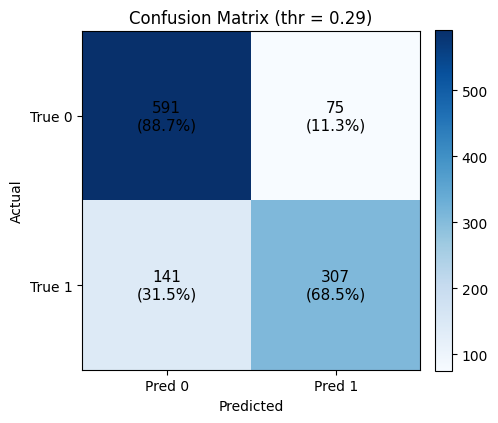

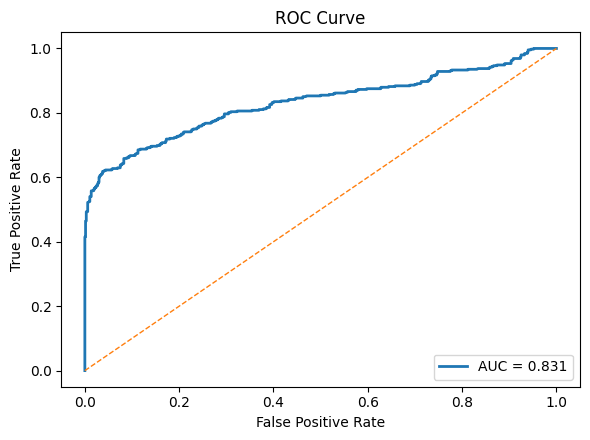

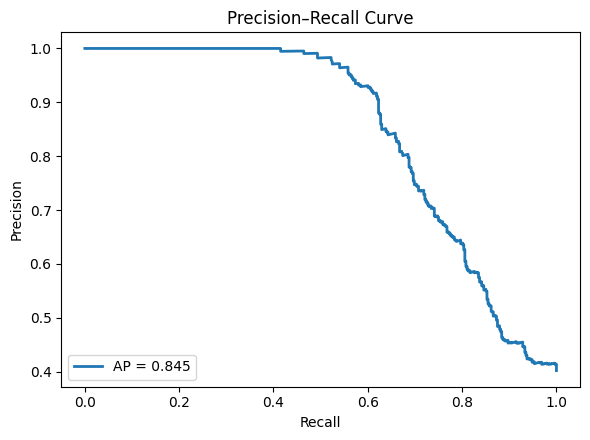

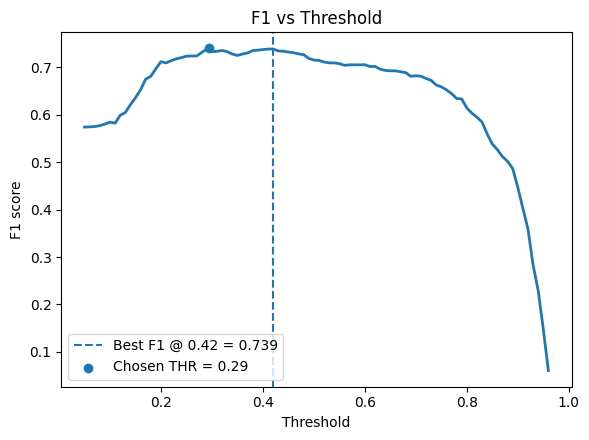

In [ ]:
# === Nice performance summary (Confusion matrix + ROC + PR + F1-threshold curve) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score, accuracy_score
)

# --- Paths & params ---
CKPT_DIR = "/content/drive/MyDrive/luna16_cls3d/fold_0"   # <— change if needed
PRED_PATH = os.path.join(CKPT_DIR, "val_predictions_resnet.csv")
AUTO_PICK_THR = True         # use best-F1 threshold found on the validation preds
THR_MANUAL   = 0.40          # only used if AUTO_PICK_THR=False

assert os.path.exists(PRED_PATH), f"Missing file: {PRED_PATH}"

# --- Load predictions ---
df = pd.read_csv(PRED_PATH)
y_true = df["label"].astype(int).to_numpy()
probs  = df["prob_pos"].astype(float).to_numpy()

# --- Choose threshold ---
if AUTO_PICK_THR:
    ths = np.linspace(0.0, 1.0, 1001)
    f1s = []
    for t in ths:
        yp = (probs >= t).astype(int)
        # skip degenerate cases where all predictions are one class
        if len(np.unique(yp)) < 2:
            f1s.append(np.nan)
        else:
            f1s.append(f1_score(y_true, yp))
    best_idx = int(np.nanargmax(f1s))
    THR = float(ths[best_idx])
else:
    THR = float(THR_MANUAL)

# --- Metrics at chosen threshold ---
y_pred = (probs >= THR).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
acc   = accuracy_score(y_true, y_pred)
prec  = (tp / (tp + fp)) if (tp + fp) > 0 else 0.0
rec   = (tp / (tp + fn)) if (tp + fn) > 0 else 0.0
spec  = (tn / (tn + fp)) if (tn + fp) > 0 else 0.0
f1    = f1_score(y_true, y_pred)

# threshold-free metrics
has_both_classes = (len(np.unique(y_true)) > 1)
auc = roc_auc_score(y_true, probs) if has_both_classes else float("nan")
ap  = average_precision_score(y_true, probs) if has_both_classes else float("nan")

print("=== Headline metrics (thr = {:.2f}) ===".format(THR))
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall (TPR)  : {rec:.4f}")
print(f"Specificity   : {spec:.4f}")
print(f"F1 score      : {f1:.4f}")
print(f"AUC (ROC)     : {auc:.4f}")
print(f"AveragePrec   : {ap:.4f}")
print(f"Confusion     : TN={tn}  FP={fp}  FN={fn}  TP={tp}")

# --- Confusion matrix plot (counts + normalized %) ---
cm = np.array([[tn, fp],
               [fn, tp]], dtype=int)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(5, 4.5))
im = plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix (thr = {THR:.2f})")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
                 ha="center", va="center", fontsize=11)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- ROC curve ---
if has_both_classes:
    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.figure(figsize=(6, 4.5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# --- Precision–Recall curve ---
if has_both_classes:
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, probs)
    plt.figure(figsize=(6, 4.5))
    plt.plot(rec_curve, prec_curve, linewidth=2, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

# --- F1 vs threshold (and highlight chosen THR) ---
ths = np.linspace(0.0, 1.0, 101)
f1s = []
for t in ths:
    yp = (probs >= t).astype(int)
    f1s.append(f1_score(y_true, yp) if len(np.unique(yp)) > 1 else np.nan)

best_idx = int(np.nanargmax(f1s))
best_thr = float(ths[best_idx])
best_f1  = float(f1s[best_idx])

plt.figure(figsize=(6, 4.5))
plt.plot(ths, f1s, linewidth=2)
plt.axvline(best_thr, linestyle="--", label=f"Best F1 @ {best_thr:.2f} = {best_f1:.3f}")
plt.scatter([THR], [f1_score(y_true, y_pred)], marker="o", label=f"Chosen THR = {THR:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# ==== Phase-3: recall-boost fine-tune (continue from best ckpt) ====
import math, random, numpy as np, torch
from torch.utils.data import DataLoader
from pathlib import Path

# --- Checkpoint paths & book-keeping ---
# Assume CKPT_DIR already exists from Phase-1/2; fall back if missing.
try:
    CKPT_DIR
except NameError:
    fold = globals().get("FOLD_ID", 0)
    CKPT_DIR = Path(f"/content/drive/MyDrive/luna16_cls3d/fold_{fold}")

# Normalize to Path, ensure directory exists
if isinstance(CKPT_DIR, str):
    CKPT_DIR = Path(CKPT_DIR)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Load previous best (Phase-2) and then save Phase-3 separately
PREV_CKPT_PATH   = CKPT_DIR / "model.pth"          # best from Phase-1/2
PHASE3_CKPT_PATH = CKPT_DIR / "model_phase3.pth"   # new file for Phase-3

# 0) Load the best checkpoint we just saved, switch to train()
state = torch.load(PREV_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.to(device=DEVICE, memory_format=torch.channels_last_3d)
model.train()

# --- Hard-positive mining (streaming) ---
def _jitter_center_mm(center_xyz, diameter_mm, cap_mm=4.0):
    amp = min(cap_mm, 0.3 * float(diameter_mm))
    j = np.random.uniform(-amp, amp, size=3)
    return (float(center_xyz[0] + j[0]),
            float(center_xyz[1] + j[1]),
            float(center_xyz[2] + j[2]))

def _pos_jitter_candidates_train(uid: str, per_nodule: int = 8):
    """Generate jittered positive centers around each labeled nodule of a scan."""
    out = []
    nods = by_uid.get(uid, [])
    if not nods:
        return out
    meta = scan_meta[uid]
    for (x, y, z, dmm) in nods:
        for _ in range(per_nodule):
            cx, cy, cz = _jitter_center_mm((x, y, z), dmm, cap_mm=6.0)
            out.append({
                "image": meta["mhd"],
                "lung":  meta["lung"],
                "center_world": (cx, cy, cz),
                "seriesuid": uid,
                "subset": meta["subset"],
            })
    return out

class _PosCandDataset(torch.utils.data.Dataset):
    """Tiny dataset to run transforms + scoring for positive candidates."""
    def __init__(self, cands, transform):
        self.cands = cands
        self.t = transform
    def __len__(self): return len(self.cands)
    def __getitem__(self, i):
        c = self.cands[i]
        s = {"image": c["image"], "center_world": np.array(c["center_world"], np.float32)}
        if c.get("lung"): s["lung"] = c["lung"]
        s["seriesuid"] = c["seriesuid"]; s["subset"] = c["subset"]
        s = self.t(s)
        return s

@torch.no_grad()
def mine_hard_positives_streaming(
    model, by_uid, scan_meta, train_uids, val_tf, device,
    per_nodule=8, keep_per_scan=6, batch_size=16, num_workers=1, prefetch_factor=1, pin=True
):
    model.eval()
    pos_uids = [u for u in train_uids if u in by_uid]
    mined = []
    for uid in pos_uids:
        cands = _pos_jitter_candidates_train(uid, per_nodule=per_nodule)
        if not cands:
            continue
        ds = _PosCandDataset(cands, transform=val_tf)
        dl = DataLoader(
            ds, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin,
            persistent_workers=False, prefetch_factor=prefetch_factor
        )
        scores = []
        for b in dl:
            x = b["image"].to(device=device, non_blocking=True, memory_format=torch.channels_last_3d)
            with amp_ctx():
                s = torch.sigmoid(model(x)).flatten().to(torch.float32)
            scores.extend(s.cpu().numpy().tolist())
        # Keep the LOWEST-scored (hardest) positives for this scan
        if scores:
            idx = np.argsort(scores)[:int(keep_per_scan)]
            for i in idx:
                c = cands[i]
                mined.append(PatchItem(
                    image=c["image"], lung=c.get("lung"), label=1,
                    center_world=tuple(map(float, c["center_world"])),
                    seriesuid=c["seriesuid"], subset=c["subset"], diam_mm=None
                ))
    print(f"[mining+] Mined {len(mined)} hard positives "
          f"(~{keep_per_scan} per positive scan; per_nodule={per_nodule})")
    model.train()
    return mined

# 1) Mine hard positives (keeps training set fixed; just adds hard examples)
HARD_POS = mine_hard_positives_streaming(
    model, by_uid, scan_meta, train_uids, val_tf, DEVICE,
    per_nodule=8, keep_per_scan=6, batch_size=BATCH_SIZE,
    num_workers=1, prefetch_factor=1, pin=(DEVICE.type=="cuda")
)

# 2) Build Phase-3 items:
#    - start from Phase-2 items
#    - add hard positives
#    - upweight positives by duplication to bias recall
base_p3 = list(train_it_phase2) + HARD_POS

POS_UPSAMPLE = 2  # duplicate positive items this many times (2 = +100% copies)
pos_items = [p for p in base_p3 if p.label == 1]
base_p3 += pos_items * (max(POS_UPSAMPLE - 1, 0))

# Cache-friendly order
train_it_phase3 = group_shuffle_by_scan(base_p3)
print(f"[phase3] Train items: {len(train_it_phase3)} "
      f"(pos={sum(p.label for p in train_it_phase3)}, neg={len(train_it_phase3)-sum(p.label for p in train_it_phase3)})")

# 3) Dataloaders (conservative workers)
train_ds = PatchDataset(train_it_phase3, transform=train_tf)
SAFE_TRAIN_WORKERS = 1
PREFETCH_TRAIN = 1
pin = (DEVICE.type == "cuda")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=SAFE_TRAIN_WORKERS, pin_memory=pin,
    persistent_workers=False, prefetch_factor=PREFETCH_TRAIN
)
# reuse val_loader as-is

# 4) Loss/optim/schedule for recall push:
#    - stronger positive weight -> penalize false negatives more
criterion = make_bce_ls_criterion(
    train_it_phase3,
    smooth_pos=0.05, smooth_neg=0.05,
    pos_weight_mode="auto",     # use neg/pos ratio
    pos_weight_scale=1.2        # >1.0 biases toward recall; tune 1.0–2.0
)

base_lr_phase3 = 3e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr_phase3, weight_decay=1e-5)
EPOCHS_PHASE3 = 2  # 2–3 is usually enough for a nudge
scheduler3 = make_scheduler(optimizer, total_epochs=EPOCHS_PHASE3, warmup_epochs=1)

# >>> Track Phase-3 separately & reset AUC tracker so we save the best-of-Phase3
best_auc = -1.0
CKPT_PATH = PHASE3_CKPT_PATH

# Free cached GPU allocations (helps validation stability)
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("[train] Starting Phase-3 (recall-boost)…")
run_training(EPOCHS_PHASE3, scheduler3, stage_name="phase3")
print("[train] Phase-3 complete.")

# (Optional) Re-calibrate temperature + re-evaluate using existing eval block,
# but point it at PHASE3_CKPT_PATH and re-run the eval/scan MIL cells.



[mining+] Mined 3204 hard positives (~6 per positive scan; per_nodule=8)
[phase3] Train items: 19808 (pos=11304, neg=8504)
[loss] pos_weight=0.903 (pos=11304 / neg=8504) | smoothing pos=0.05 neg=0.05
[train] Starting Phase-3 (recall-boost)…
[train]phase3 Start: epochs=2
[train]phase3 Epoch 01 — lr=3.00e-06 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase3 Ep 01:   0%|          | 0/300 [00:00<?, ?it/s]

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase3 | AUC=0.8645 | BestF1=0.7587 @ thr=0.15
[ckpt]phase3 ✔ saved: /content/drive/MyDrive/luna16_cls3d/fold_0/model_phase3.pth
[train]phase3 Epoch 02 — lr=3.00e-05 — trainable params: 11,243,649 — steps/epoch: 300


[train]phase3 Ep 02:   0%|          | 0/300 [00:00<?, ?it/s]

[val] batches:   0%|          | 0/140 [00:00<?, ?it/s]

[val]phase3 | AUC=0.8572 | BestF1=0.7829 @ thr=0.40
[early-stop]phase3 stagnation=1/3
[train] Phase-3 complete.


In [ ]:
# ==== Phase-3: temperature calibration + re-evaluation ====
import os, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

# ---------- Paths / model load ----------
try:
    CKPT_DIR
except NameError:
    CKPT_DIR = Path(f"/content/drive/MyDrive/luna16_cls3d/fold_{globals().get('FOLD_ID', 0)}")
if isinstance(CKPT_DIR, str):
    CKPT_DIR = Path(CKPT_DIR)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PHASE3_CKPT_PATH = CKPT_DIR / "model_phase3.pth"
FALLBACK_CKPT    = CKPT_DIR / "model.pth"   # if phase3 wasn't saved for some reason

ckpt_to_load = PHASE3_CKPT_PATH if PHASE3_CKPT_PATH.exists() else FALLBACK_CKPT
print(f"[ckpt] Loading for eval/calibration: {ckpt_to_load}")

state = torch.load(ckpt_to_load, map_location=DEVICE)
model.load_state_dict(state)
model.to(device=DEVICE, memory_format=torch.channels_last_3d)
model.eval()

# ---------- TTA helpers (flips only) ----------
import torch.nn.functional as F

USE_TTA_IN_EVAL = True
TTA_CFG = dict(use_flips=True, use_rot=False)

@torch.no_grad()
def tta_mean_logits(x, model, cfg=TTA_CFG):
    variants = [("id", ())]
    if cfg.get("use_flips", True):
        variants += [("flipD", (2,)), ("flipH", (3,)), ("flipW", (4,))]
    logits_sum = torch.zeros((x.size(0),), dtype=torch.float32, device=x.device)
    n = 0
    for _, aug in variants:
        x_aug = torch.flip(x, dims=aug) if aug else x
        with amp_ctx():
            logit = model(x_aug).flatten().to(torch.float32)
        logits_sum += logit; n += 1
    return logits_sum / max(n, 1)

# ---------- Collect logits/targets from val_loader ----------
@torch.no_grad()
def collect_val_logits_targets(val_loader):
    model.eval()
    logits_all, targs_all, subsets = [], [], []
    for b in val_loader:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        y = b["label"].to(DEVICE, non_blocking=True).float()
        if USE_TTA_IN_EVAL:
            logit = tta_mean_logits(x, model, TTA_CFG)
        else:
            with amp_ctx():
                logit = model(x).flatten().to(torch.float32)
        logits_all.append(logit.detach().cpu())
        targs_all.append(y.detach().cpu())
        subs = b.get("subset", None)
        if isinstance(subs, list):
            subsets.extend(subs)
        elif subs is None:
            subsets.extend(["unknown"] * len(y))
        else:
            subsets.extend([subs] * len(y))
    if logits_all:
        logits = torch.cat(logits_all, dim=0)
        targs  = torch.cat(targs_all,  dim=0)
    else:
        logits = torch.empty(0); targs = torch.empty(0)
    return logits, targs, subsets

# ---------- Temperature calibration ----------
def calibrate_temperature(logits, targets, max_iter=300):
    """Optimize scalar temperature T to minimize BCEWithLogits NLL."""
    if logits.numel() == 0:
        print("[calib] No logits to calibrate; using T=1.0")
        return 1.0
    log_T = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([log_T], lr=0.5, max_iter=max_iter, line_search_fn="strong_wolfe")
    bce = nn.BCEWithLogitsLoss()
    def closure():
        opt.zero_grad(set_to_none=True)
        T = torch.exp(log_T)
        loss = bce(logits / T, targets)
        loss.backward()
        return loss
    opt.step(closure)
    T = float(torch.exp(log_T).detach().cpu())
    print(f"[calib] Optimized temperature T={T:.4f}")
    return T

# ---------- Run calibration ----------
val_logits, val_targets, val_subsets = collect_val_logits_targets(val_loader)
TEMP_P3 = calibrate_temperature(val_logits, val_targets)
with open(CKPT_DIR / "calibration_phase3.json", "w") as f:
    json.dump({"temperature": float(TEMP_P3)}, f)

# ---------- Final PATCH-level evaluation (calibrated + TTA flips) ----------
all_probs, all_targs, all_subsets = [], [], []
with torch.no_grad():
    for b in val_loader:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        y = b["label"].float().cpu().numpy().ravel()
        if USE_TTA_IN_EVAL:
            logit = tta_mean_logits(x, model, TTA_CFG).cpu().numpy().ravel()
        else:
            with amp_ctx():
                logit = model(x).flatten().cpu().numpy().ravel()
        prob = 1.0 / (1.0 + np.exp(-logit / max(TEMP_P3, 1e-6)))  # calibrated
        all_probs.extend(prob.tolist()); all_targs.extend(y.tolist())
        subs = b.get("subset", None)
        if isinstance(subs, list):
            all_subsets.extend(subs)
        elif subs is None:
            all_subsets.extend(["unknown"] * len(prob))
        else:
            all_subsets.extend([subs] * len(prob))

all_probs = np.array(all_probs, dtype=np.float32)
all_targs = np.array(all_targs, dtype=np.int32)

# AUC + best-F1 threshold sweep (0.05..0.95)
if len(all_probs) == 0:
    print("[final][patch:P3] No validation predictions to evaluate.")
else:
    auc = roc_auc_score(all_targs, all_probs) if np.unique(all_targs).size > 1 else float("nan")
    thrs = np.linspace(0.05, 0.95, 19)
    best_f1, best_thr = -1.0, 0.5
    for t in thrs:
        pred = (all_probs >= t).astype(int)
        if pred.min() == pred.max(): continue
        f1 = f1_score(all_targs, pred)
        if f1 > best_f1:
            best_f1, best_thr = f1, t
    if best_f1 < 0: best_f1, best_thr = float("nan"), 0.5

    pred = (all_probs >= best_thr).astype(int)
    if np.unique(all_targs).size == 2:
        tn, fp, fn, tp = confusion_matrix(all_targs, pred, labels=[0, 1]).ravel()
    else:
        tn = fp = fn = tp = 0

    print(f"[final][patch:P3] VAL (calibrated, TTA flips): AUC={auc:.4f} | best F1={best_f1:.4f} @ thr={best_thr:.2f} | T={TEMP_P3:.3f}")
    print(f"[final][patch:P3] Confusion @ {best_thr:.2f}: TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    # Save per-subset AUC + per-sample predictions
    from collections import defaultdict
    by_s = defaultdict(lambda: {"p": [], "y": []})
    for p, y, s in zip(all_probs, all_targs, all_subsets):
        by_s[s]["p"].append(float(p)); by_s[s]["y"].append(int(y))

    rows = []
    for s in sorted(by_s.keys()):
        p = np.array(by_s[s]["p"], dtype=np.float32)
        y = np.array(by_s[s]["y"], dtype=np.int32)
        auc_s = roc_auc_score(y, p) if np.unique(y).size > 1 else float("nan")
        rows.append({"subset": s, "n": int(len(y)), "pos_rate": float(y.mean()), "auc": float(auc_s)})

    pd.DataFrame(rows).to_csv(CKPT_DIR / "val_subset_auc_phase3.csv", index=False)
    pd.DataFrame({"subset": all_subsets, "label": all_targs, "prob_pos": all_probs}) \
      .to_csv(CKPT_DIR / "val_predictions_phase3.csv", index=False)

    print(f"[save] Wrote: {CKPT_DIR/'val_subset_auc_phase3.csv'}")
    print(f"[save] Wrote: {CKPT_DIR/'val_predictions_phase3.csv'}")

# ---------- Scan-level MIL evaluation (same settings, using calibrated T) ----------
# Fallback helpers in case they aren't in scope
try:
    _sample_candidates_for_scan
except NameError:
    import SimpleITK as sitk
    def _sample_candidates_for_scan(uid: str, meta: dict, n_candidates: int = 64):
        out = []
        img = sitk.ReadImage(str(meta["mhd"]))
        size_xyz = img.GetSize()
        def _index_to_world(ix, iy, iz):
            return img.TransformIndexToPhysicalPoint((ix, iy, iz))
        for _ in range(n_candidates):
            rx = np.random.uniform(0.1, 0.9); ry = np.random.uniform(0.1, 0.9); rz = np.random.uniform(0.1, 0.9)
            ix = int(rx * max(1, size_xyz[0]-1))
            iy = int(ry * max(1, size_xyz[1]-1))
            iz = int(rz * max(1, size_xyz[2]-1))
            w = _index_to_world(ix, iy, iz)
            out.append({
                "image": meta["mhd"], "lung": meta["lung"],
                "center_world": (float(w[0]), float(w[1]), float(w[2])),
                "seriesuid": uid, "subset": meta["subset"]
            })
        return out

def _pos_jitter_candidates(uid: str, per_nodule: int = 2):
    out = []
    nods = by_uid.get(uid, [])
    meta = scan_meta[uid]
    for (x, y, z, dmm) in nods:
        for _ in range(per_nodule):
            j = np.random.uniform(-min(4.0, 0.3*dmm), min(4.0, 0.3*dmm), size=3)
            out.append({
                "image": meta["mhd"], "lung": meta["lung"],
                "center_world": (float(x+j[0]), float(y+j[1]), float(z+j[2])),
                "seriesuid": uid, "subset": meta["subset"]
            })
    return out

from torch.utils.data import Dataset, DataLoader

class _MiningEvalDS(Dataset):
    def __init__(self, cands, transform): self.cands, self.t = cands, transform
    def __len__(self): return len(self.cands)
    def __getitem__(self, i):
        c = self.cands[i]
        s = {"image": c["image"], "center_world": np.array(c["center_world"], np.float32)}
        if c.get("lung"): s["lung"] = c["lung"]
        s["seriesuid"] = c["seriesuid"]; s["subset"] = c["subset"]
        return self.t(s)

@torch.no_grad()
def evaluate_scan_level_mil_p3(val_uids: set, random_per_scan=64, pos_jitter_per_nodule=2, temperature=1.0):
    from collections import defaultdict
    all_cands = []
    for uid in sorted(val_uids):
        meta = scan_meta[uid]
        all_cands += _sample_candidates_for_scan(uid, meta, n_candidates=random_per_scan)
        if pos_jitter_per_nodule > 0 and uid in by_uid:
            all_cands += _pos_jitter_candidates(uid, per_nodule=pos_jitter_per_nodule)

    if not all_cands:
        print("[scan:P3] No MIL candidates generated.")
        return float("nan")

    ds = _MiningEvalDS(all_cands, transform=val_tf)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=0, pin_memory=(DEVICE.type=="cuda"))

    by_uid_scores = defaultdict(list)
    model.eval()
    for b in dl:
        x = b["image"].to(device=DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
        if USE_TTA_IN_EVAL:
            logit = tta_mean_logits(x, model, TTA_CFG)
        else:
            with amp_ctx():
                logit = model(x).flatten().to(torch.float32)
        prob = torch.sigmoid(logit / max(temperature, 1e-6)).detach().cpu().numpy().ravel()
        for i, uid in enumerate(b["seriesuid"]):
            by_uid_scores[uid].append(float(prob[i]))

    y_true, p_max, p_mean = [], [], []
    for uid in sorted(val_uids):
        scores = by_uid_scores.get(uid, [0.0])
        y_true.append(1 if uid in pos_set else 0)
        p_max.append(float(np.max(scores)))
        p_mean.append(float(np.mean(scores)))

    y_true = np.array(y_true, dtype=np.int32)
    p_max  = np.array(p_max, dtype=np.float32)
    p_mean = np.array(p_mean, dtype=np.float32)

    auc_max  = roc_auc_score(y_true, p_max)  if np.unique(y_true).size > 1 else float("nan")
    auc_mean = roc_auc_score(y_true, p_mean) if np.unique(y_true).size > 1 else float("nan")

    pd.DataFrame({
        "seriesuid": sorted(val_uids),
        "label": y_true,
        "prob_max": p_max,
        "prob_mean": p_mean
    }).to_csv(CKPT_DIR / "val_scan_predictions_phase3.csv", index=False)

    print(f"[final][scan:P3] MIL AUC (max-agg) = {auc_max:.4f} | MIL AUC (mean-agg) = {auc_mean:.4f} "
          f"| N_random/scan={random_per_scan} | pos_jitter/nd={pos_jitter_per_nodule}")
    print(f"[save] Wrote: {CKPT_DIR/'val_scan_predictions_phase3.csv'}")
    return float(auc_max)

# Run scan-level MIL eval with same settings used before
_ = evaluate_scan_level_mil_p3(
    val_uids=val_uids,
    random_per_scan=64,
    pos_jitter_per_nodule=2,
    temperature=TEMP_P3
)


[ckpt] Loading for eval/calibration: /content/drive/MyDrive/luna16_cls3d/fold_0/model_phase3.pth
[calib] Optimized temperature T=1.4783
[final][patch:P3] VAL (calibrated, TTA flips): AUC=0.8645 | best F1=0.7500 @ thr=0.20 | T=1.478
[final][patch:P3] Confusion @ 0.20: TN=499  FP=167  FN=79  TP=369
[save] Wrote: /content/drive/MyDrive/luna16_cls3d/fold_0/val_subset_auc_phase3.csv
[save] Wrote: /content/drive/MyDrive/luna16_cls3d/fold_0/val_predictions_phase3.csv
[final][scan:P3] MIL AUC (max-agg) = 0.9227 | MIL AUC (mean-agg) = 0.8643 | N_random/scan=64 | pos_jitter/nd=2
[save] Wrote: /content/drive/MyDrive/luna16_cls3d/fold_0/val_scan_predictions_phase3.csv
